# **Clusterring **

## Marketing Analytics : Online Shoppens Intention

### **Executive Summary**
The primary objective of this analysis is customer segmentation based entirely on user browsing behavior. Using a dataset of 12,330 online shopping sessions, we apply unsupervised machine learning techniques to discover hidden consumer profiles.

Our workflow includes:
*   **Data Preparation:** Dropping the target variable (`Revenue`) to prevent data leakage, handling missing values, and scaling the features.
*   **Exploratory Data Analysis (EDA):** Visualizing data distributions, identifying outliers through boxplots, and checking for multicollinearity using a correlation heatmap.
*   **Clustering & Dimensionality Reduction:** Implementing the K-Means algorithm to group similar sessions, and utilizing techniques like PCA and t-SNE to visualize the resulting clusters in a lower-dimensional space.

# 1. Imports & Loading the Data

In [2]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


RANDOOM_STATE = 42
sns.set_style("whitegrid")

In [3]:
#load the data
df = pd.read_csv("../ek_assignment_folder/data/online_shoppers_intention.csv")

In [4]:
# print the dataset
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (12330, 18)


In [5]:
#print the first 5 rows of the dataset
display(df.head())

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [6]:
#information about the dataset
print("Dataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  T

# 2. Data Cleaning & Dropping Target Variables

In unsupervised learning tasks like clustering, the algorithm must discover hidden patterns strictly based on user behavior, without knowing the actual outcomes. Therefore, it is absolutely critical to remove the target variable (e.g., `Revenue`) from our dataset to prevent data leakage. We also drop any missing values to ensure the mathematical distance calculations—which algorithms like K-Means heavily rely on—can function correctly without errors.

In [7]:
#data cleaning
print("========== Starting Data Cleaning ==========")

#drop missing values
df_clean = df.dropna().copy()
print(f"\nMissing values dropped. Remaining dataset shape: {df_clean.shape}")

#remove target variable from features- this is unsupervised learning
df_clean_no_target = df_clean.drop(columns=['Revenue'])
print("\nTarget variable 'Revenue' removed in order to avoid data leakage.")
print(f"Dataset shape after removing target variable: {df_clean_no_target.shape}")


========== Starting Data Cleaning ==========

Missing values dropped. Remaining dataset shape: (12330, 18)

Target variable 'Revenue' removed in order to avoid data leakage.
Dataset shape after removing target variable: (12330, 17)


# 3. Explanatory Data Analysis (EDA)

Before applying distance-based clustering algorithms like K-Means, it is essential to understand the distribution of our features and, most importantly, to identify outliers. Distance metrics are highly sensitive to extreme values, which can distort cluster boundaries and artificially pull centroids away from dense data regions. 

In this section, we generate summary statistics and visualize the distributions using Boxplots to detect any severe anomalies that might require capping or removal before scaling. We also use a Correlation Heatmap to check for highly redundant features.


============= 1.Summary Statistics: =================


,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000



============= 2. Outliers Detection (Boxplots): =================


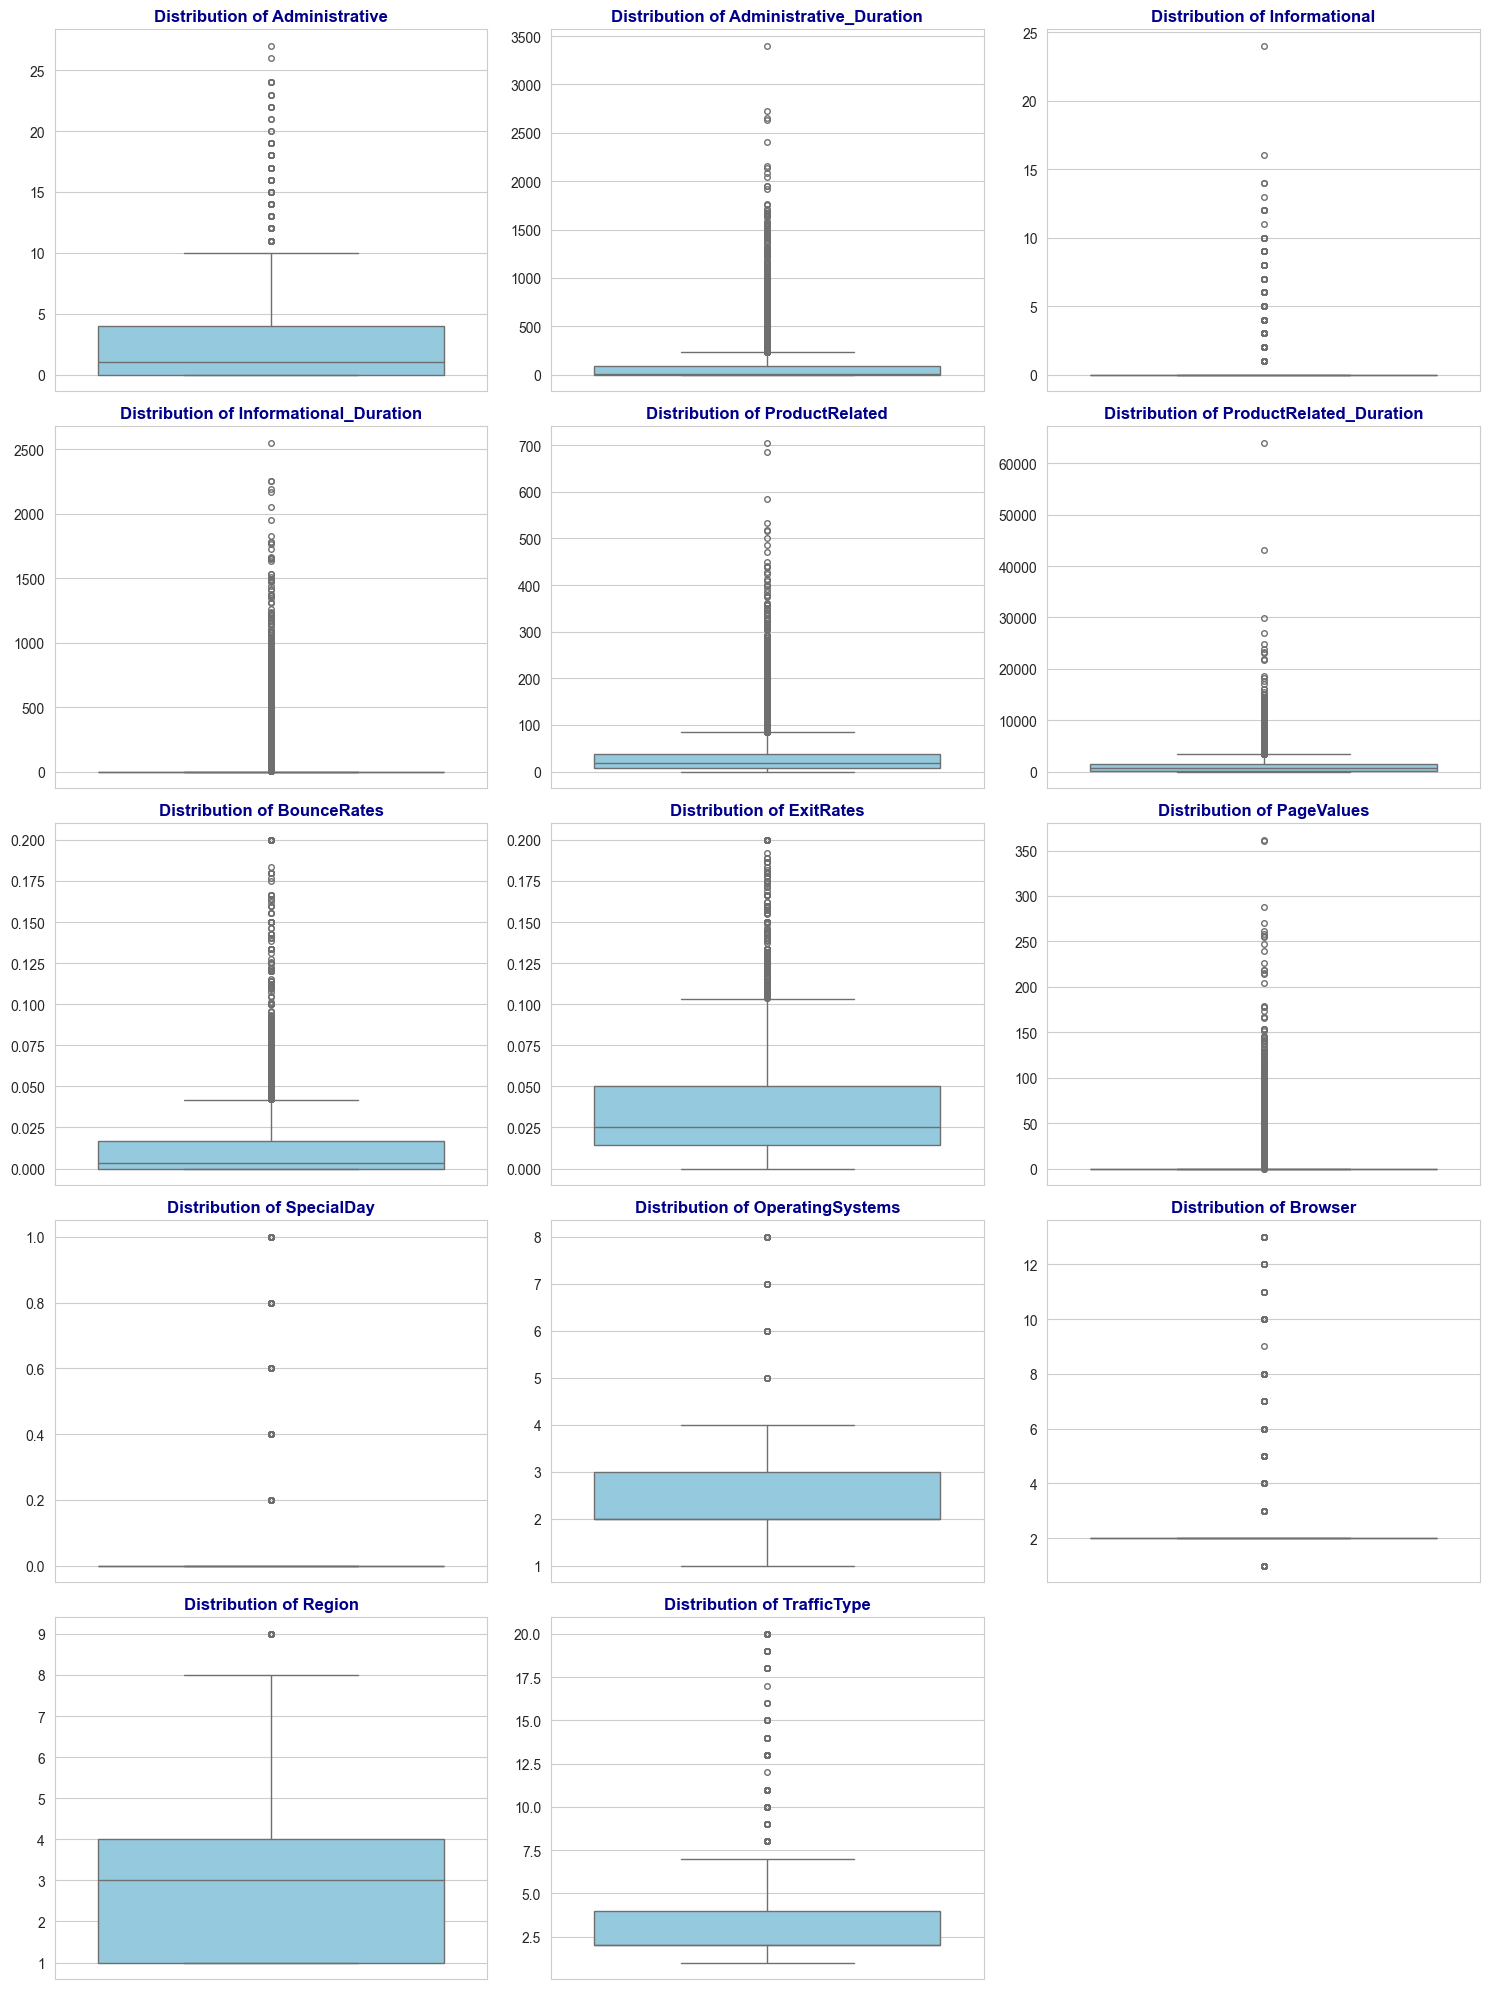


============= 3. Feature Distribution Histograms: =================


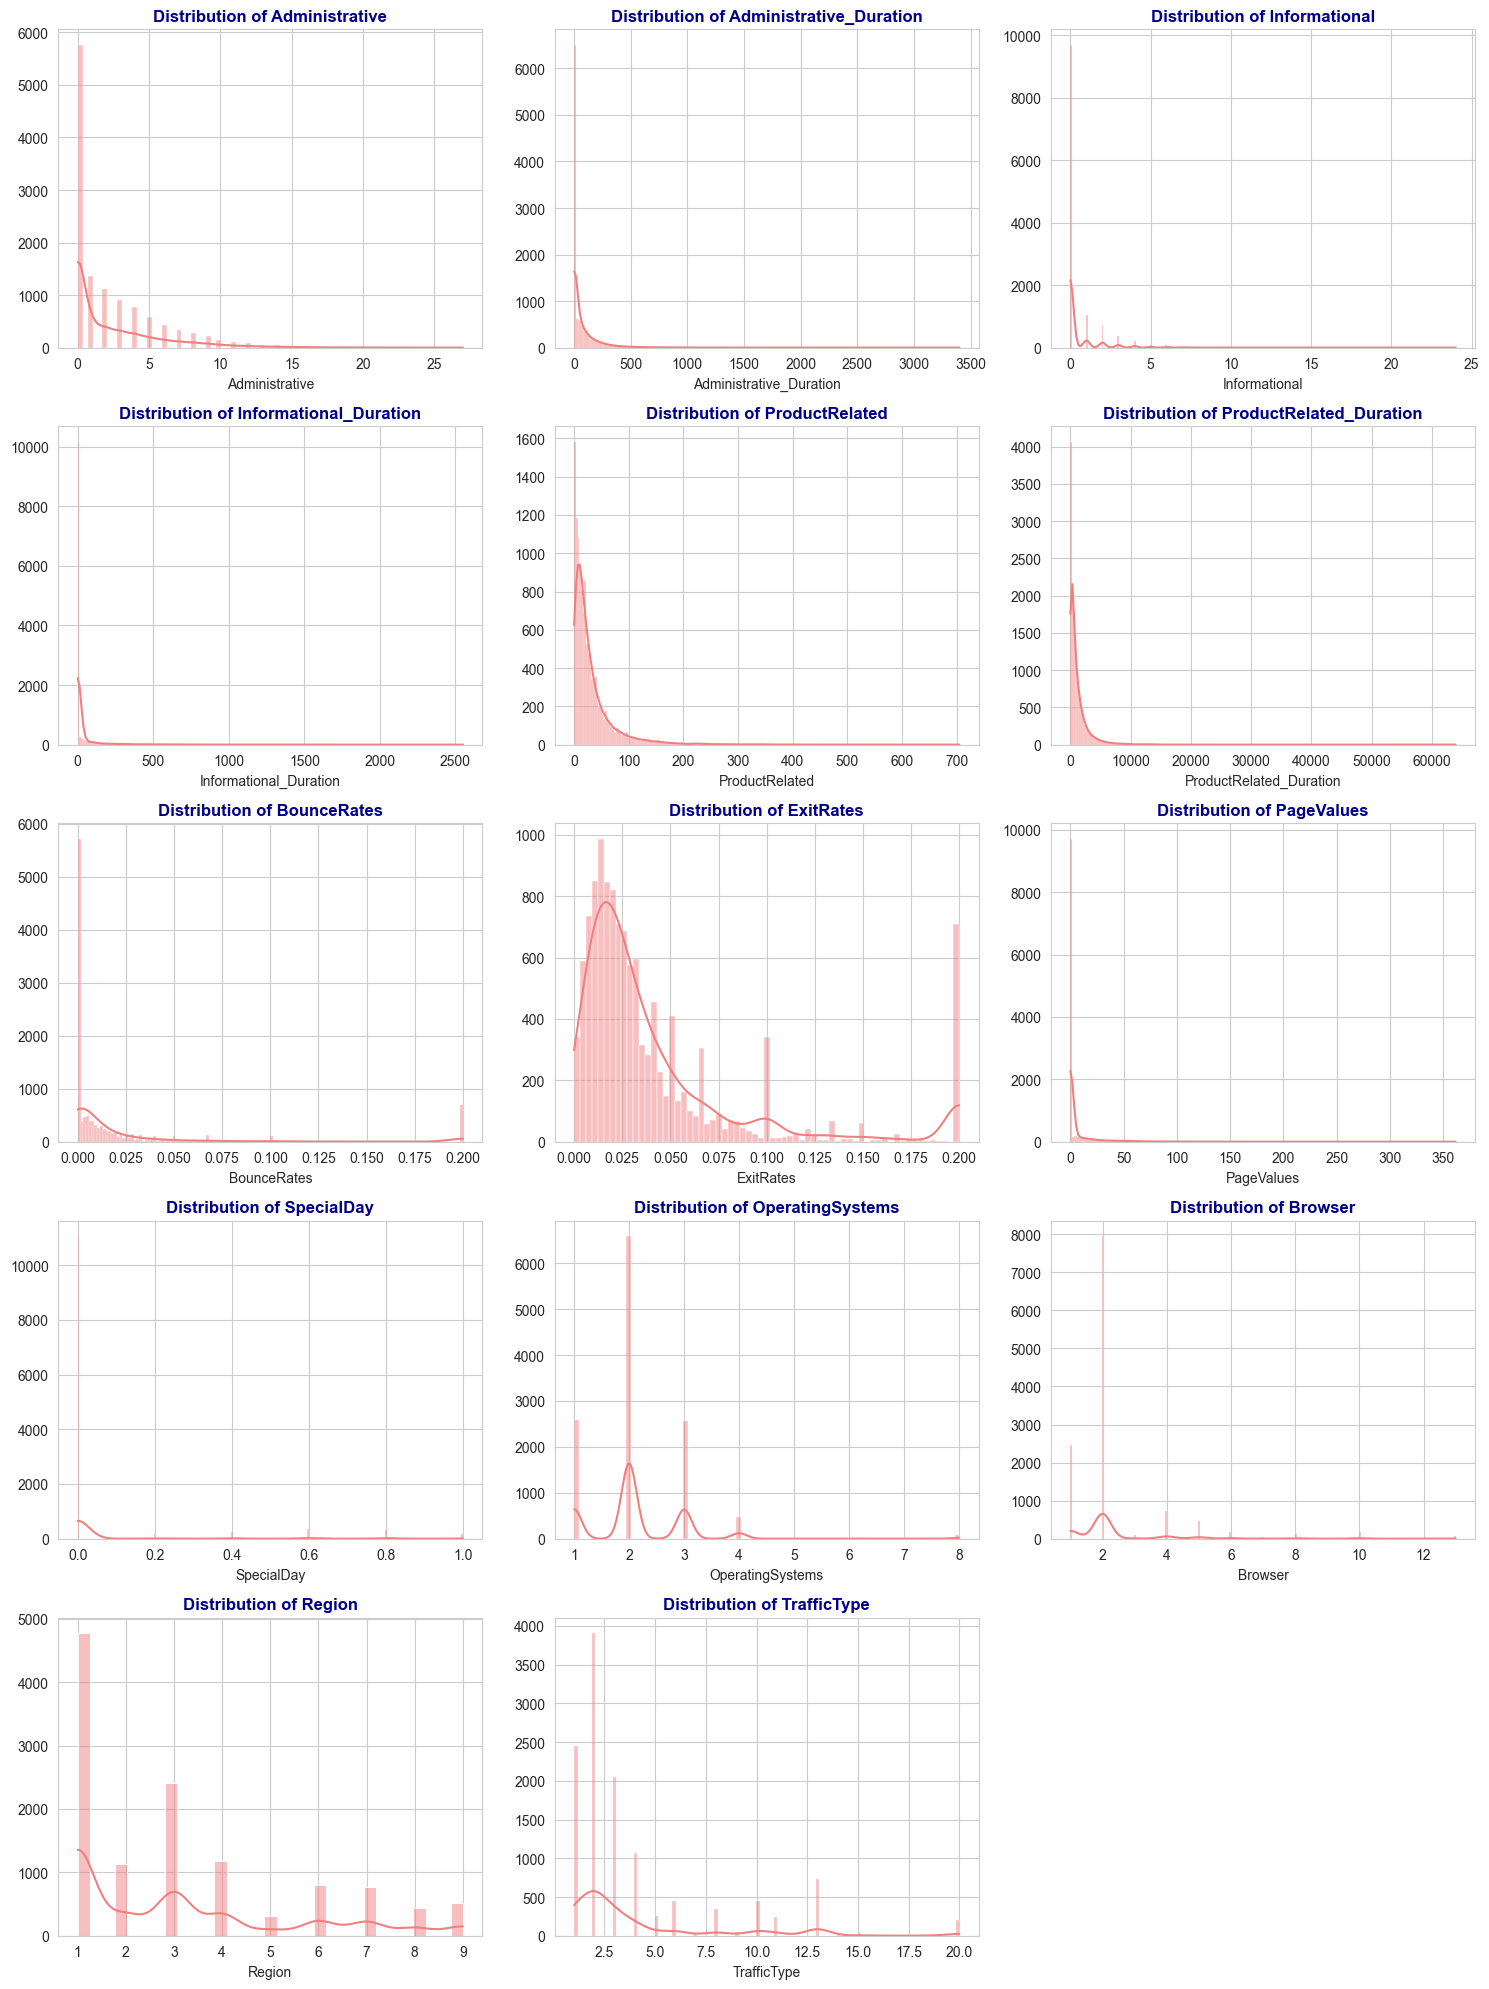

In [8]:
#summary statistics
print("\n============= 1.Summary Statistics: =================")
display(df_clean_no_target.describe().T) #we use .T to transpose the output for better readability

print("\n============= 2. Outliers Detection (Boxplots): =================")
#we will use boxplots to detect outliers in the numerical features
num_cols = df_clean_no_target.select_dtypes(include=['int64', 'float64','int32','float32']).columns

#calculate plot dimensions (3 plots per row)
rows = (len(num_cols) // 3) + 1
fig, axes = plt.subplots(rows, 3, figsize=(15, rows * 4), dpi=100)
axes = axes.flatten()  # Flatten the axes array for easy iteration

#create boxplots for each numerical feature
for i, col in enumerate(num_cols):
    sns.boxplot(y=df_clean_no_target[col], ax=axes[i], color='skyblue',fliersize=4)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold',color='darkblue')
    axes[i].set_ylabel('')

#remove empty subplots(if any columns are not a multiple of 3)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

#feature distribution histograms
print("\n============= 3. Feature Distribution Histograms: =================")
fig, axes = plt.subplots(rows, 3, figsize=(15, rows * 4), dpi=100)
axes = axes.flatten()  # Flatten the axes array for easy iteration

for i, col in enumerate(num_cols):
    sns.histplot(df_clean_no_target[col], ax=axes[i], kde=True, color='lightcoral')
    axes[i].set_title(f'Distribution of {col}', fontweight='bold',color='darkblue')
    axes[i].set_ylabel('')

#remove empty subplots(if any columns are not a multiple of 3)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


============= 4. Correlation Heatmap: =================


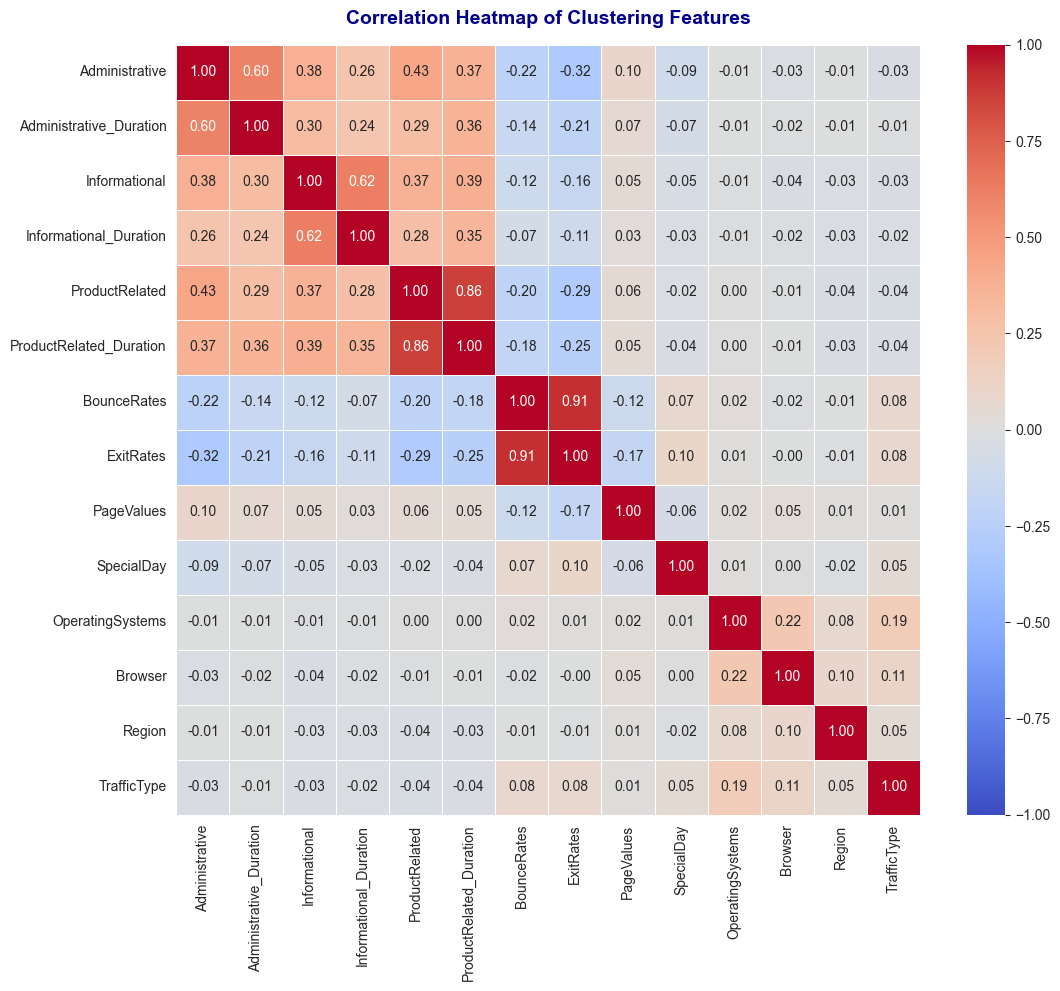


========== Post-EDA Data Processing ==========

Dropped 'BounceRates' due to high correlation with 'ExitRates' that we identified through the Heatmap.

Dropped anonymized technical ID columns (clustering stays behavioural): ['OperatingSystems', 'Browser', 'Region', 'TrafficType']

One-hot encoding applied to categorical variables. Dataset shape after encoding: (12330, 21)

Applied log1p to skewed count/duration features: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'PageValues']

Columns after encoding:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,ExitRates,PageValues,SpecialDay,Weekend,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0.0,0.0,0.0,0.0,0.693147,0.000000,0.20,0.0,0.0,0,...,1,0,0,0,0,0,0,0,0,1
1,0.0,0.0,0.0,0.0,1.098612,4.174387,0.10,0.0,0.0,0,...,1,0,0,0,0,0,0,0,0,1
2,0.0,0.0,0.0,0.0,0.693147,0.000000,0.20,0.0,0.0,0,...,1,0,0,0,0,0,0,0,0,1
3,0.0,0.0,0.0,0.0,1.098612,1.299283,0.14,0.0,0.0,0,...,1,0,0,0,0,0,0,0,0,1
4,0.0,0.0,0.0,0.0,2.397895,6.443336,0.05,0.0,0.0,1,...,1,0,0,0,0,0,0,0,0,1


In [9]:
#correlation heatmap
print("\n============= 4. Correlation Heatmap: =================")
plt.figure(figsize=(12, 10), dpi=100)
sns.heatmap(
    df_clean_no_target.select_dtypes(include=[np.number]).corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title('Correlation Heatmap of Clustering Features', fontweight='bold',color='darkblue', fontsize=14,pad=15) 
plt.show()

#after our eda, we came back to further clean the data
print("\n========== Post-EDA Data Processing ==========")

#drop one of the two highly correlated features: 'ExitRates' and 'BounceRates'
if 'BounceRates' in df_clean_no_target.columns:
    df_clean_no_target = df_clean_no_target.drop(columns=['BounceRates'])
    print("\nDropped 'BounceRates' due to high correlation with 'ExitRates' that we identified through the Heatmap.")

#OperatingSystems, Browser, Region and TrafficType are anonymized technical CATEGORY IDs - they carry no
#behavioural meaning and are not quantities. One-hot encoding them adds ~45 sparse columns whose rare
#levels explode under scaling and dominate K-Means. We therefore exclude them and segment purely on
#visitor BEHAVIOUR (page visits, durations, exit rates, page values, month, visitor type, weekend).
id_cols = ['OperatingSystems', 'Browser', 'Region', 'TrafficType']
df_clean_no_target = df_clean_no_target.drop(columns=id_cols)
print(f"\nDropped anonymized technical ID columns (clustering stays behavioural): {id_cols}")

#one-hot encode the remaining categorical variables (Month, VisitorType) to prepare for clustering
df_clean_no_target_encoded = pd.get_dummies(df_clean_no_target, drop_first=True, dtype=int)

#Weekend is boolean -> cast to 0/1 int so it behaves as a plain binary feature downstream
bool_cols = df_clean_no_target_encoded.select_dtypes('bool').columns
df_clean_no_target_encoded[bool_cols] = df_clean_no_target_encoded[bool_cols].astype(int)
print(f"\nOne-hot encoding applied to categorical variables. Dataset shape after encoding: {df_clean_no_target_encoded.shape}")

#the count/duration features are heavily right-skewed and all >= 0. StandardScaler centers/scales but does
#NOT bound the range, so without this the extreme tails (scaled z-scores up to ~33) dominate K-Means'
#squared Euclidean distance and get isolated into tiny outlier clusters. log1p compresses that tail
#(this is the 'capping/removal' step our EDA flagged but never actually applied).
skewed_cols = ['Administrative', 'Administrative_Duration', 'Informational',
               'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'PageValues']
df_clean_no_target_encoded[skewed_cols] = np.log1p(df_clean_no_target_encoded[skewed_cols])
print(f"\nApplied log1p to skewed count/duration features: {skewed_cols}")

#show columns after encoding to make sure that all features are now numeric and bouncerates is dropped
print("\nColumns after encoding:")
display(df_clean_no_target_encoded.head())

# 4. Feature Scaling (log1p + Standardization)

K-Means relies entirely on Euclidean distances, so feature scale and shape matter. Two issues in our data had to be handled before scaling:

1. **Heavy skew.** The page-count and duration features are extremely right-skewed — a few sessions have enormous durations/counts. We apply a `log1p` transform to these so that a handful of power-users don't dominate the distance metric (`log1p` because the features are counts/durations that are always `>= 0`).
2. **Mixed feature types.** We have continuous behavioural features alongside binary `0/1` one-hot dummies (Month, VisitorType, Weekend). We standardize **only the continuous features** with `StandardScaler` (mean 0, std 1) and deliberately leave the binary columns on their natural `0/1` scale. Standardizing a *rare* dummy would turn it into a huge z-score (a category appearing a few times in 12,330 rows becomes a ~100σ spike) and let a single rare category dominate the clustering.

In [10]:
#apply standard scaling to the CONTINUOUS features only
print("\n============= Applying Standardization (StandardScaler) =================")

#standardizing the one-hot dummies / the binary Weekend flag would let a rare category (e.g. a month that
#occurs a handful of times) blow up to a huge z-score and dominate the Euclidean distance. So we scale ONLY
#the continuous behavioural features and leave the binary columns on their natural 0/1 scale.
continuous_cols = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration',
                   'ProductRelated', 'ProductRelated_Duration', 'PageValues', 'ExitRates', 'SpecialDay']
scaler = StandardScaler()

#copy the encoded frame, then standardize the continuous columns in place (keeps column names + index)
df_scaled = df_clean_no_target_encoded.astype(float).copy()
df_scaled[continuous_cols] = scaler.fit_transform(df_scaled[continuous_cols])

print("\nStandard scaling applied to the continuous features. Here are the first 5 rows of the scaled dataset:")
display(df_scaled.head())

#reassure that the continuous features are now centered (binary dummies intentionally remain 0/1)
print("\nSummary Statistics of Scaled Features:")
display(df_scaled.describe().round(2).T)


============= Applying Standardization (StandardScaler) =================

Standard scaling applied to the continuous features. Here are the first 5 rows of the scaled dataset:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,ExitRates,PageValues,SpecialDay,Weekend,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,-0.923678,-0.975402,-0.478085,-0.464858,-1.950729,-2.918505,3.229316,-0.492303,-0.308821,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.923678,-0.975402,-0.478085,-0.464858,-1.589955,-0.875249,1.171473,-0.492303,-0.308821,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.923678,-0.975402,-0.478085,-0.464858,-1.950729,-2.918505,3.229316,-0.492303,-0.308821,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.923678,-0.975402,-0.478085,-0.464858,-1.589955,-2.282539,1.994610,-0.492303,-0.308821,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.923678,-0.975402,-0.478085,-0.464858,-0.433884,0.235343,0.142551,-0.492303,-0.308821,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0



Summary Statistics of Scaled Features:


,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,-0.00,1.00,-0.92,-0.92,-0.12,0.94,2.94
Administrative_Duration,12330.0,0.00,1.00,-0.98,-0.98,-0.07,0.95,2.46
Informational,12330.0,-0.00,1.00,-0.48,-0.48,-0.48,-0.48,6.02
Informational_Duration,12330.0,-0.00,1.00,-0.46,-0.46,-0.46,-0.46,3.85
ProductRelated,12330.0,0.00,1.00,-2.57,-0.72,0.05,0.69,3.27
ProductRelated_Duration,12330.0,-0.00,1.00,-2.92,-0.36,0.21,0.65,2.50
ExitRates,12330.0,0.00,1.00,-0.89,-0.59,-0.37,0.14,3.23
PageValues,12330.0,-0.00,1.00,-0.49,-0.49,-0.49,-0.49,4.16
SpecialDay,12330.0,0.00,1.00,-0.31,-0.31,-0.31,-0.31,4.72
Weekend,12330.0,0.23,0.42,0.00,0.00,0.00,0.00,1.00


# 5. Finding the Optimal Number of Clusters

As demonstrated in the lecture materials, K-Means requires the number of clusters ($k$) to be specified in advance. To make an objective, data-driven decision, we evaluate models with $k$ ranging from 2 to 10 using two complementary metrics:

1. **The Elbow Method (Inertia):** Evaluates cluster compactness (Within-Cluster Sum of Squares). We look for the "elbow" point where the rate of improvement sharply drops.
2. **The Silhouette Score:** Evaluates both cluster cohesion and separation. It ranges from -1 to 1, with higher scores indicating better-defined clusters.

By plotting both metrics side-by-side, we can confidently identify the optimal configuration for our customer segmentation.


============= Elbow Method and Silhouette Scores (k=2 to 10) =============

Trials are completed. Now we move on to plotting the results.


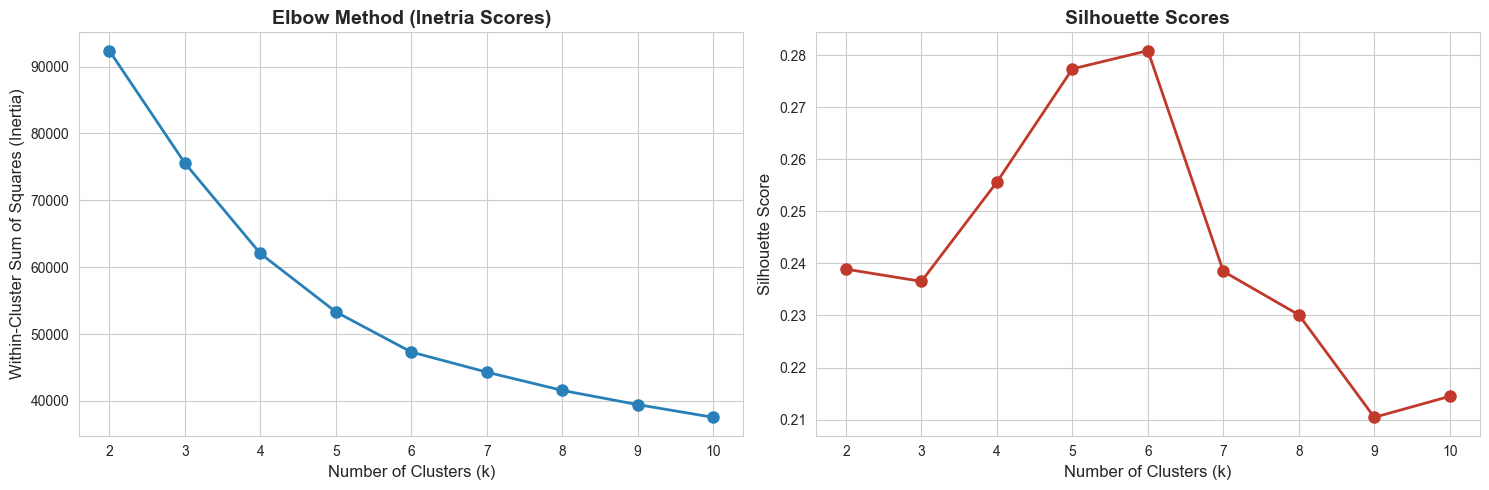

In [11]:
#calculate Elbow Method and Silhouette Scores to determine the optimal number of clusters
print("\n============= Elbow Method and Silhouette Scores (k=2 to 10) =============")

#lists to store the inertia and silhouette scores for each k
inertia_scores = []
silhouette_scores = []
K_range = range(2, 11)

#start the loop to calculate scores for each k
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOOM_STATE, n_init=10)
    #train in the scaled data
    cluster_labels = kmeans.fit_predict(df_scaled)
    #store metrics
    inertia_scores.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, cluster_labels))

print("\nTrials are completed. Now we move on to plotting the results.")

#plot the Elbow Method results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), dpi=100)
ax1.plot(K_range, inertia_scores, marker='o', color='#2980B9',linewidth=2, markersize=8)
ax1.set_title('Elbow Method (Inetria Scores)', fontweight='bold', fontsize=14)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Within-Cluster Sum of Squares (Inertia)', fontsize=12)
ax1.set_xticks(K_range)

#plot the Silhouette Scores
ax2.plot(K_range, silhouette_scores, marker='o', color='#C0392B',linewidth=2, markersize=8)
ax2.set_title('Silhouette Scores', fontweight='bold', fontsize=14)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_xticks(K_range)

plt.tight_layout()
plt.show()

### Interpretation of Results & Final Selection (k=4)

We balance mathematical cohesion against business utility:

1. **Elbow Method (Inertia):** Inertia falls steeply through k=2→4 and then the rate of improvement clearly slows, placing the "elbow" around **k=4**. Adding clusters beyond this gives diminishing returns in variance reduction.
2. **Silhouette Score:** Scores are healthy and stable across the whole range (~0.24–0.28), rising only gently to a mild peak around k=5–6. There is no single dominant peak, so the silhouette does not by itself force a particular k — and at **k=4** it is already strong (~0.26).

**Business Decision:** Because the silhouette is comparably good across k=4–6, we let business utility break the tie. **$k=4$** sits right at the inertia elbow, keeps the segments interpretable for a marketing strategy, and (as the profiling below shows) produces four well-balanced groups with a clean low→high conversion gradient. Splitting into 5–6 clusters would only carve these into finer slices with little extra separation.

Therefore, we will proceed to fit our final K-Means model using **4 clusters**.

# 6. Apply Algorithms - Kmeans Using ML Pipelines

Having selected $k=4$, we build the final model as a Scikit-Learn `Pipeline` so the preprocessing and the model travel together as one reusable, reproducible object — the exact same steps are then applied to any new visitor in Section 8.

The pipeline chains a `ColumnTransformer` — which standardizes **only the continuous features** and passes the binary dummies through untouched (`remainder='passthrough'`) — with our `KMeans` algorithm. We feed it the encoded, already `log1p`-transformed behavioural data, and the pipeline applies the scaling before the distance calculations.

Following the parameter configurations from our lecture notes (`lec_09e`), we initialize KMeans with:
* `n_clusters=4`
* `init='k-means++'` (Smart initialization)
* `n_init=10` (Multiple centroid seeds)
* `random_state=42` (Reproducibility)

In [12]:
print("\n============ Fiting KMeans (k=4) using Pipeline =================")

#scale ONLY the continuous features inside the pipeline; the binary dummies / Weekend are passed through
#untouched. This mirrors the manual scaling above and avoids rare one-hot categories dominating distance.
continuous_cols = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration',
                   'ProductRelated', 'ProductRelated_Duration', 'PageValues', 'ExitRates', 'SpecialDay']
preprocessor = ColumnTransformer(
    transformers=[('scale_continuous', StandardScaler(), continuous_cols)],
    remainder='passthrough'
)

#create a pipeline that includes the (continuous-only) scaling and KMeans clustering
clustering_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('kmeans', KMeans(n_clusters=4, init='k-means++', random_state=RANDOOM_STATE, n_init=10))
])

#train and predict cluster labels using the pipeline
#we fit the pipeline to the encoded (already log1p'd) data, and it applies the scaling before clustering
cluster_labels = clustering_pipe.fit_predict(df_clean_no_target_encoded)

#add the cluster labels to the original cleaned dataset (before encoding) for easier interpretation
df_clean['Cluster'] = cluster_labels
print("\nThe Pipeline has been fitted and cluster labels have been assigned to the original cleaned dataset.")
print("\nHere are the first 5 rows of the dataset with cluster labels:")
display(df_clean.head())

#now we can analyze how many vistors are in each cluster
print("\n-------------Visitor Distribution Across Clusters:----------------")
cluster_counts = df_clean['Cluster'].value_counts().sort_index()
for cluster_num, count in cluster_counts.items():
    print(f"Cluster {cluster_num}: {count} visitors ({(count/len(df_clean)*100):.2f}%)")
    


============ Fiting KMeans (k=4) using Pipeline =================

The Pipeline has been fitted and cluster labels have been assigned to the original cleaned dataset.

Here are the first 5 rows of the dataset with cluster labels:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,Cluster
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False,1
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False,1
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False,1
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False,1
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False,3



-------------Visitor Distribution Across Clusters:----------------
Cluster 0: 4167 visitors (33.80%)
Cluster 1: 1205 visitors (9.77%)
Cluster 2: 2184 visitors (17.71%)
Cluster 3: 4774 visitors (38.72%)


# 7. Cluster Profiling and Interpretation

Now that our algorithm has assigned every visitor to one of the 4 clusters, we must translate these mathematical groupings into **Business Personas**. K-Means does not cluster based on a single feature, but evaluates the holistic combination of all 21 behavioural dimensions simultaneously.

Our methodology for profiling is as follows:
1. **Business Profiling (Conversion Rate & Behavior):** We re-introduce our hidden target variable (`Revenue`) to calculate the actual conversion rate of each cluster. We also normalize the feature means to visualize which specific behaviors (e.g., page durations, exit rates) define each group via a Heatmap.
2. **3D Cluster Validation (PCA vs. t-SNE):** To visually validate our 4 distinct customer personas, we reduce our 21-dimensional feature space into 3 dimensions. We compare **PCA** (which preserves global structure) with **t-SNE** (which is optimized for finding local non-linear neighborhoods), ensuring our clusters are geometrically distinct.


-------------Buisness Profiling of Clusters:----------------

Cluster Profiling Summary (Mean Values of Numeric Features):


Cluster,0,1,2,3
Administrative,4.00,0.07,5.21,0.09
Administrative_Duration,138.72,1.49,189.32,0.66
Informational,0.05,0.02,2.61,0.06
Informational_Duration,0.06,0.15,191.73,1.24
ProductRelated,35.69,2.09,66.51,19.85
ProductRelated_Duration,1284.31,20.59,2640.24,751.66
BounceRates,0.01,0.14,0.01,0.01
ExitRates,0.02,0.17,0.02,0.04
PageValues,8.40,0.00,8.77,3.86
SpecialDay,0.03,0.08,0.03,0.10


C:\Users\Elena\AppData\Local\Temp\ipykernel_1164\1671215538.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary.index, y=cluster_summary['Revenue'] * 100, palette='coolwarm', ax=ax1)


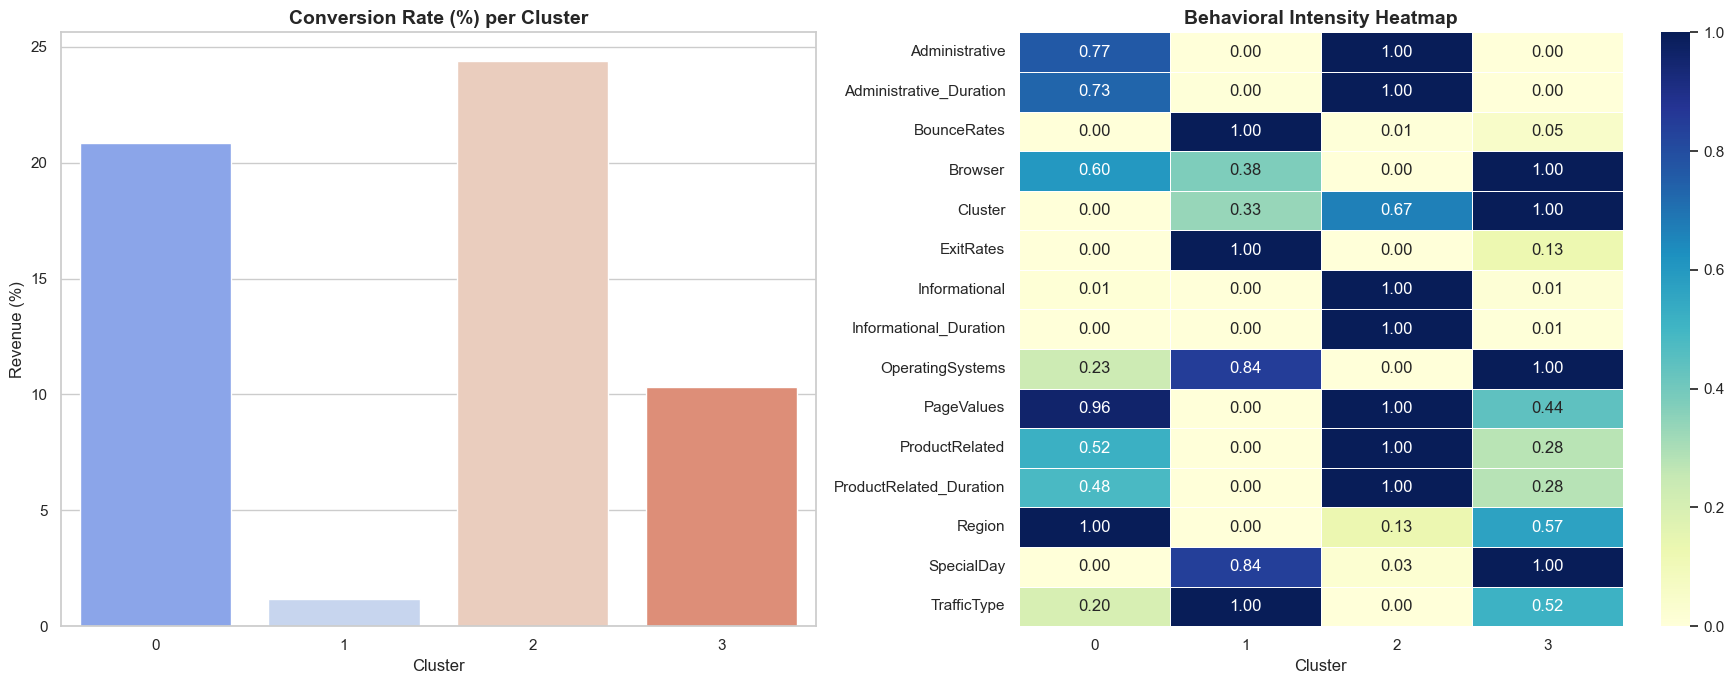

In [13]:
#profilling 
print("\n-------------Buisness Profiling of Clusters:----------------")

#we have to make sure that revenue is a numeric variable for our profiling, so we convert it to int (0 and 1)
if df_clean['Revenue'].dtype == 'bool' or df_clean['Revenue'].dtype == 'object':
    df_clean['Revenue'] = df_clean['Revenue'].astype(int)

#calculate the mean of each numeric feature for each cluster to understand the characteristics of each cluster
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
cluster_summary = df_clean.groupby('Cluster')[numeric_cols].mean()

#print the summary statistics for each cluster
print("\nCluster Profiling Summary (Mean Values of Numeric Features):")
display(cluster_summary.T.round(2))

#create two plots side by side to visualize the average revenue and average exit rates for each cluster
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), dpi=100)

#left plot: bar plot of conversion rate (average revenue) for each cluster
sns.barplot(x=cluster_summary.index, y=cluster_summary['Revenue'] * 100, palette='coolwarm', ax=ax1)
ax1.set_title('Conversion Rate (%) per Cluster', fontweight='bold', fontsize=14)
ax1.set_xlabel('Cluster', fontsize=12)
ax1.set_ylabel('Revenue (%)', fontsize=12)

#right plot: heatmap of behavioral features (average exit rates, page values, etc.) for each cluster in 0-1 scale
features_to_plot = cluster_summary.columns.difference(['Revenue'])  # Exclude 'Revenue' from the heatmap
scaler_geo = MinMaxScaler()
summary_scaled = pd.DataFrame(
    scaler_geo.fit_transform(cluster_summary[features_to_plot]),
    columns=features_to_plot,
    index=cluster_summary.index
)
sns.heatmap(summary_scaled.T, annot=True, cmap='YlGnBu', fmt=".2f", ax=ax2, linewidths=0.5)
ax2.set_title('Behavioral Intensity Heatmap', fontweight='bold', fontsize=14)
ax2.set_xlabel('Cluster', fontsize=12)

plt.tight_layout()
plt.show()

In [14]:
#3D PCA Visualization of Clusters VS t-SNE Visualization of Clusters
print("\n-------------3D Visualization (PCA vs t-SNE):----------------")

#reduce the scaled feature space (df_scaled) down to 3 components for plotting.
#PCA keeps global/linear structure; t-SNE captures local non-linear neighborhoods.
#NOTE: these projections are for VISUALIZATION ONLY - the clusters were already fit on the full feature space.
print("\nRunning PCA (3 components)...")
X_pca_3d = PCA(n_components=3, random_state=RANDOOM_STATE).fit_transform(df_scaled)

print("Running t-SNE (3 components) - this can take a minute or two on 12k rows...")
X_tsne_3d = TSNE(
    n_components=3,
    random_state=RANDOOM_STATE,
    init='pca',
    learning_rate='auto',
    perplexity=30
).fit_transform(df_scaled)

#we will use plotly for interactive 3D visualizations of the clusters in both PCA and t-SNE reduced spaces
#we have to convert the cluster labels to a categorical variable for better visualization
cluster_labels_cat = df_clean['Cluster'].astype(str)  # Convert cluster labels to string for categorical coloring

#PCA for 3D visualization
df_pca_plotly = pd.DataFrame(X_pca_3d, columns=['PCA1', 'PCA2', 'PCA3'])
df_pca_plotly['Cluster'] = cluster_labels_cat  # Add cluster labels for coloring

fig_pca = px.scatter_3d(
    df_pca_plotly,
    x='PCA1',
    y='PCA2',
    z='PCA3',
    color='Cluster',
    title='Interactive 3D PCA Visualization of Clusters',
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Set1
)

#make the dots smaller for better visibility
fig_pca.update_traces(marker=dict(size=4))
fig_pca.show()

#t-SNE for 3D visualization
df_tsne_plotly = pd.DataFrame(X_tsne_3d, columns=['tSNE1', 'tSNE2', 'tSNE3'])
df_tsne_plotly['Cluster'] = cluster_labels_cat  # Add cluster labels for coloring

fig_tsne = px.scatter_3d(
    df_tsne_plotly,
    x='tSNE1',
    y='tSNE2',
    z='tSNE3',
    color='Cluster',
    title='Interactive 3D t-SNE Visualization of Clusters',
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Set1
)

#make the dots smaller for better visibility
fig_tsne.update_traces(marker=dict(size=4))
fig_tsne.show()


-------------3D Visualization (PCA vs t-SNE):----------------

Running PCA (3 components)...
Running t-SNE (3 components) - this can take a minute or two on 12k rows...


## 8. Production Simulation: Predicting a New Visitor

The ultimate goal of customer segmentation is real-time personalization. Since we structured our K-Means algorithm inside a Scikit-Learn `Pipeline` (which encompasses both the `StandardScaler` and the model), we can seamlessly classify new traffic. 

In this section, we simulate a scenario where a new user enters the website, browses several products, and generates a behavioral footprint. We pass this footprint directly into our pipeline to predict their Cluster and instantly trigger the appropriate marketing strategy.


In [15]:
#try to identify the cluster that has a higher conversion rate (revenue) 

print("\n-------------Identifying the Cluster with Higher Conversion Rate:----------------")
#the mean of the revenue for each cluster
conversion_rates = df_clean.groupby('Cluster')['Revenue'].mean()

# id.max() returns the index of the maximum value in the conversion_rates series, which corresponds to the cluster with the highest conversion rate
vip_cluster_id = conversion_rates.idxmax()
max_conversion = conversion_rates.max() * 100
print(f"\nCluster {vip_cluster_id} has the highest conversion rate of {max_conversion:.2f}%. This cluster can be considered as the VIP cluster with the most valuable customers.")

# classify a new visitor into one of the clusters
print("\n-------------Classifying a New Visitor:----------------")

#we will create a new visitor by using the data of an existing visitor from the dataset, but we will change some of the values to make it a new visitor
new_visitor = df_clean_no_target_encoded.iloc[[0]].copy()  # Start with the first visitor's data (already in the log1p space)

# we alter the behaviour of the new visitor to make it different from the original one.
# the skewed count/duration features were log1p-transformed during preprocessing, so we must apply
# the SAME log1p to the raw values we inject here, otherwise the new visitor would be on a different scale.
new_visitor['Administrative'] = np.log1p(5)                 # 5 administrative pages visited
new_visitor['ProductRelated_Duration'] = np.log1p(2500.00) # 2500s total on product-related pages
new_visitor['ProductRelated'] = np.log1p(10)               # 10 product-related pages visited
new_visitor['PageValues'] = np.log1p(10.00)                # average page value of 10
new_visitor['ExitRates'] = 0.05  # ExitRates is a 0-1 rate, NOT log-transformed

print("\nNew Visitor's data have been collected")

#the prediction using the trained pipeline
predicted_cluster = clustering_pipe.predict(new_visitor)
print(f"\nThe new visitor is classified into Cluster {predicted_cluster[0]}.")

#the buisness interpretation of the predicted cluster
print("\n-------------Business Interpretation of the Predicted Cluster:----------------")

#see if the predicted cluster is the VIP cluster we identified earlier
if predicted_cluster[0] == vip_cluster_id:
    print(f"\nThe new visitor is classified into Cluster {predicted_cluster[0]}, which is the VIP cluster.")
else:
    print(f"\nThe new visitor is classified into Cluster {predicted_cluster[0]}, which is not the VIP cluster.")   


-------------Identifying the Cluster with Higher Conversion Rate:----------------

Cluster 2 has the highest conversion rate of 24.40%. This cluster can be considered as the VIP cluster with the most valuable customers.

-------------Classifying a New Visitor:----------------

New Visitor's data have been collected

The new visitor is classified into Cluster 0.

-------------Business Interpretation of the Predicted Cluster:----------------

The new visitor is classified into Cluster 0, which is not the VIP cluster.
